In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))


**<font size="6" color="red">ch1. NLTK 자연어처리 패키지</font>**
```
자연어처리 : 텍스트 전처리, 단어의 빈도수 측정, 문서유사도 측정, 연관분석, 딥러닝,
                   워드임베딩, 텍스트분류, 어휘 데이터 베이스 사용, 감정분석, 분류분석
```
# 1. NLTK 패키지
- 텍스트 전처리, 단어빈도수 측정 : 토큰화(문장, 어절, 형태소 나누기), 정규표현식을 이용한 불용어처리, 어간추출,
- 품사태깅 : 단어별 품사를 식별
* pip install nltk==3.7

In [2]:
import nltk

In [3]:
# 말뭉치들 다운로드 받을 폴더(book 선택 후 다운로드)
# c:/nltk_data, e:/nltk_data, c:/Users/내컴퓨터이름/nltk_data
# c:/Users/내컴퓨터이름/anacond3/nltk_data
# c:/Users/내컴퓨터이름/AppData/nltk_data
# c:/Users/내컴퓨터이름/anacond3/lib/nltk_data
# c:/Users/내컴퓨터이름/anacond3/share/nltk_data
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [4]:
# 말뭉치 리스트
nltk.corpus.gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [6]:
emma = nltk.corpus.gutenberg.raw("austen-emma.txt")

In [9]:
print(emma[:30])
print(type(emma))
print('글자수 :', len(emma))

[Emma by Jane Austen 1816]

VO
<class 'str'>
글자수 : 887071


In [14]:
# sent_tokenize() 문장 단위로 나눈 list 반환
from nltk.tokenize import sent_tokenize
sent_tokens = sent_tokenize(emma)
print('문장수 :', len(sent_tokens))
print('첫문장 :', sent_tokens[1])

문장수 : 7456
첫문장 : She was the youngest of the two daughters of a most affectionate,
indulgent father; and had, in consequence of her sister's marriage,
been mistress of his house from a very early period.


In [16]:
# word_tokenize() : 단어 단위로 쪼갠 list반환
from nltk.tokenize import word_tokenize
print(word_tokenize(sent_tokens[0]))

['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', ',', 'handsome', ',', 'clever', ',', 'and', 'rich', ',', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', ',', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', ';', 'and', 'had', 'lived', 'nearly', 'twenty-one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her', '.']


In [21]:
# RegexpTokenizer 클래스 : 정규표현식을 이용한 토큰화 작업을 하기 위함
from nltk.tokenize import RegexpTokenizer
ret = RegexpTokenizer('\d+')      # \d+ = [0-9]
digits = ret.tokenize(emma)
print(digits)
ret1 = RegexpTokenizer('\w+')   # \w+ = [a-zA-Z0-9]+
words = ret1.tokenize(sent_tokens[0])
print(words)
ret2 = RegexpTokenizer('[a-zA-Z]+')   # 해당 정규표현식에 맞는 단어만 추출
words2 = ret2.tokenize(sent_tokens[0])
print(words2)

['1816', '8', '23', '28', '28', '24', '7', '10', '000', '10', '000', '26']
['Emma', 'by', 'Jane', 'Austen', '1816', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', 'handsome', 'clever', 'and', 'rich', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', 'and', 'had', 'lived', 'nearly', 'twenty', 'one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her']
['Emma', 'by', 'Jane', 'Austen', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', 'handsome', 'clever', 'and', 'rich', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', 'and', 'had', 'lived', 'nearly', 'twenty', 'one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her']


# 2. 형태소(의미가 있는 가장 작은 단위) 분석
- 자연어 처리의 기본 : 형태소 분석과 품사태깅 - 어간추출(Stemmer), 품사태깅(pos_tag)

In [23]:
words = ['sending', 'cooking', 'files', 'lives', 'crying', 'dying']
# 어간추출1 : PorterStemmer
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer
pst = PorterStemmer()
[pst.stem(word) for word in words]

['send', 'cook', 'file', 'live', 'cri', 'die']

In [24]:
# 어간추출2 : LancasterStemmer
lst = LancasterStemmer()
[lst.stem(word) for word in words]

['send', 'cook', 'fil', 'liv', 'cry', 'dying']

In [25]:
# 어간추출3 : RegexpStemmer
rst = RegexpStemmer('ing')
[rst.stem(word) for word in words]

['send', 'cook', 'files', 'lives', 'cry', 'dy']

# 3. 품사태깅
- https://dbrang.tistory.com/1139

In [29]:
from nltk.tag import pos_tag
tagged_list = pos_tag(word_tokenize(sent_tokens[0]) )
print('품사태깅 결과 :', tagged_list)

품사태깅 결과 : [('[', 'NNS'), ('Emma', 'NNP'), ('by', 'IN'), ('Jane', 'NNP'), ('Austen', 'NNP'), ('1816', 'CD'), (']', 'NNP'), ('VOLUME', 'NNP'), ('I', 'PRP'), ('CHAPTER', 'VBP'), ('I', 'PRP'), ('Emma', 'NNP'), ('Woodhouse', 'NNP'), (',', ','), ('handsome', 'NN'), (',', ','), ('clever', 'NN'), (',', ','), ('and', 'CC'), ('rich', 'JJ'), (',', ','), ('with', 'IN'), ('a', 'DT'), ('comfortable', 'JJ'), ('home', 'NN'), ('and', 'CC'), ('happy', 'JJ'), ('disposition', 'NN'), (',', ','), ('seemed', 'VBD'), ('to', 'TO'), ('unite', 'VB'), ('some', 'DT'), ('of', 'IN'), ('the', 'DT'), ('best', 'JJS'), ('blessings', 'NNS'), ('of', 'IN'), ('existence', 'NN'), (';', ':'), ('and', 'CC'), ('had', 'VBD'), ('lived', 'VBN'), ('nearly', 'RB'), ('twenty-one', 'CD'), ('years', 'NNS'), ('in', 'IN'), ('the', 'DT'), ('world', 'NN'), ('with', 'IN'), ('very', 'RB'), ('little', 'JJ'), ('to', 'TO'), ('distress', 'VB'), ('or', 'CC'), ('vex', 'VB'), ('her', 'PRP'), ('.', '.')]


In [35]:
# 명사만 추출 : NN, NNS, NNP, NNPS
nouns_list = []
for word, tag in tagged_list:
# 1   if (tag=='NN') | (tag=='NNS') | (tag=='NNP') | (tag=='NNPS'):
    if tag in ['NN', 'NNS', 'NNP', 'NNPS']:
# 3  if tag.find('NN')!= -1:
        nouns_list.append(word)
print(nouns_list)

['[', 'Emma', 'Jane', 'Austen', ']', 'VOLUME', 'Emma', 'Woodhouse', 'handsome', 'clever', 'home', 'disposition', 'blessings', 'existence', 'years', 'world']


In [39]:
nonus_list = [word for word, tag in tagged_list if tag in ['NN', 'NNS', 'NNP', 'NNPS'] ] 
print(nouns_list)

['[', 'Emma', 'Jane', 'Austen', ']', 'VOLUME', 'Emma', 'Woodhouse', 'handsome', 'clever', 'home', 'disposition', 'blessings', 'existence', 'years', 'world']


## Quiz. emma 소설안에서
1. 특수문자가 들어가지 않은 3글자 이상의 단어(RegespTokenizer)만 추출해서 품사태깅(pos_tag)하세요
2. 'Emma' 단어가 몇번 등장했는지, 품사태깅이 어떤 품사들(set)로 되어 있는지 모두 출력하시오.
3. 내가 원하는 특정 품사(명사: NN, NNS, NNP, NNPS)만 뽑아 등장하는 명사의 종류 개수 출력하시오.

- NN : 일반 단수 명사 / NNS : 일반 복수 명사
- NNP : 고유명사 단수 / NNPS : 고유명사 복수

In [121]:
from nltk.tokenize import RegexpTokenizer

ret1 = RegexpTokenizer('\w{3,}')
words = ret1.tokenize(emma)

tagged_list1 = pos_tag(words)
print('글자수 :', len(emma))
print('단어 출현 수 :', len(words), len(tagged_list))
print('단어 종류 수(겹치는 단어 제외) :', len(set(words)), len(set(tagged_list)))

글자수 : 887071
단어 출현 수 : 123877 58
단어 종류 수(겹치는 단어 제외) : 7630 46


In [124]:
count = 0
emma_tag = []

for word, tag in tagged_list1:
    if word == 'Emma':
        count += 1
        emma_tag.append(tag)

print('Emma 등장 횟수 :', count)
print('분류된 품사들 :', pos)

Emma 등장 횟수 : 865
분류된 품사들 : {'NNP'}


In [148]:
nouns_list = []

for word, tag in tagged_list1:
    if tag in ['NN', 'NNS', 'NNP', 'NNPS']:
        nouns_list.append(word)

print(len(set(nouns_list)))

# nouns_list = [word for word, tag in tagged_list if tag in noun_tags]

4165


In [149]:
# Series 이용
import pandas as pd
pos = set(emma_tag)
pos_cnt = pd.Series([0]*len(pos), index=pos)

for word, tag in tagged_list1:
    if word == 'Emma':
        pos_cnt[tag] += 1

pos_cnt

VBP       4
VB        5
VBN       1
JJ        4
NN        7
NNPS      2
VBD       1
RB        1
NNS       2
NNP     838
dtype: int64

In [150]:
pos_cnt = dict()
for word, tag in tagged_list1:
    if word == 'Emma':
        if tag in pos_cnt:
            pos_cnt[tag] += 1
        else:
            pos_cnt[tag] = 1
pos_cnt

{'NNP': 838,
 'VBP': 4,
 'JJ': 4,
 'VB': 5,
 'NNS': 2,
 'RB': 1,
 'NN': 7,
 'NNPS': 2,
 'VBN': 1,
 'VBD': 1}

In [151]:
# pos_cnt.items()
sorted(pos_cnt.items(), key=lambda x:x[1])

[('RB', 1),
 ('VBN', 1),
 ('VBD', 1),
 ('NNS', 2),
 ('NNPS', 2),
 ('VBP', 4),
 ('JJ', 4),
 ('VB', 5),
 ('NN', 7),
 ('NNP', 838)]

# 4. 최빈 단어 시각화

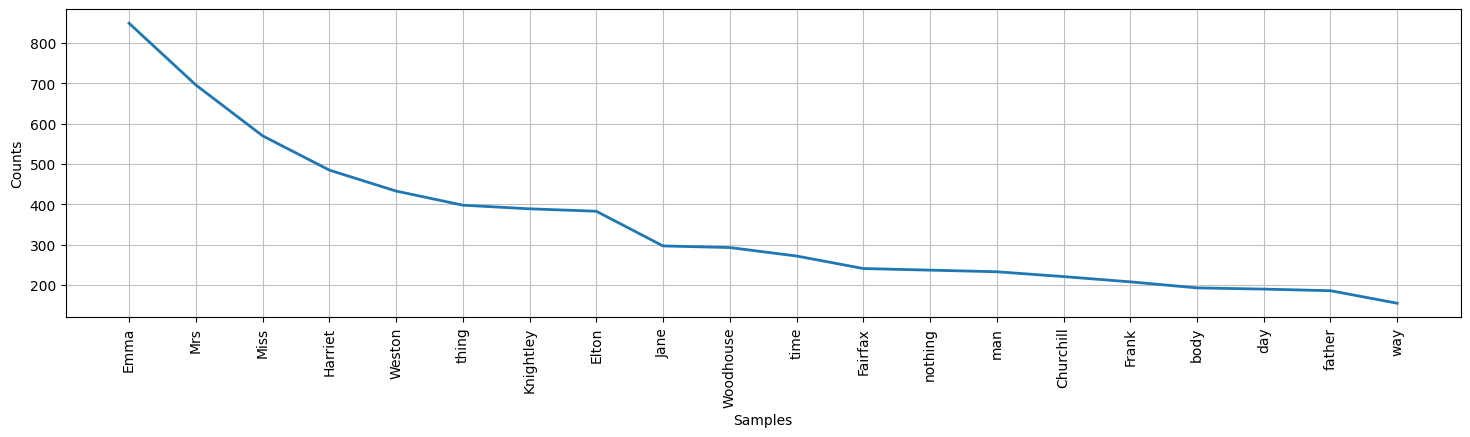

In [152]:
import matplotlib.pyplot as plt
from nltk import Text

# Text : 단어리스트와 관련된 빈도분석이나 단어검색을 쉽게 처리할 수 있는 클래스
emma_text = Text(nouns_list)
plt.figure(figsize=(18,4))
emma_text.plot(20)
plt.show()

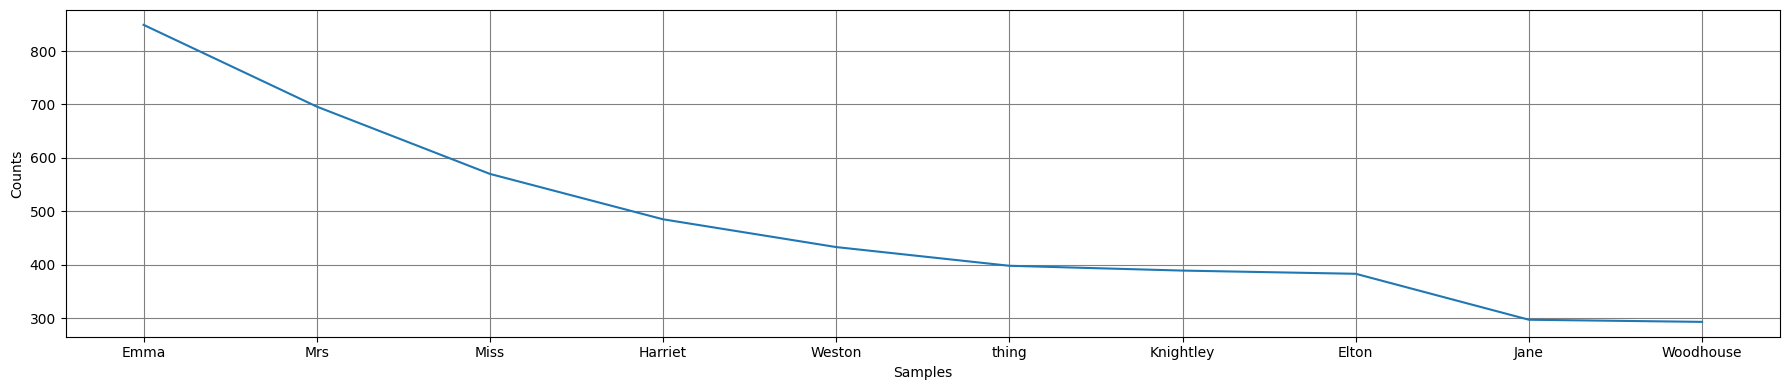

In [153]:
freqDist = emma_text.vocab()
# print(freqDist)
most_common = freqDist.most_common(10) # 상위 10개
most_common
xlabel = [word for word, count in most_common]
yvalue = [count for word, count in most_common]
plt.figure(figsize=(18,4))
plt.plot(xlabel, yvalue, marker=None)
# plt.xticks(rotation=45)
plt.xlabel('Samples')
plt.ylabel('Counts')
plt.grid(color='gray')
plt.tight_layout()
plt.show()

In [154]:
emma_text.count('Emma')

849

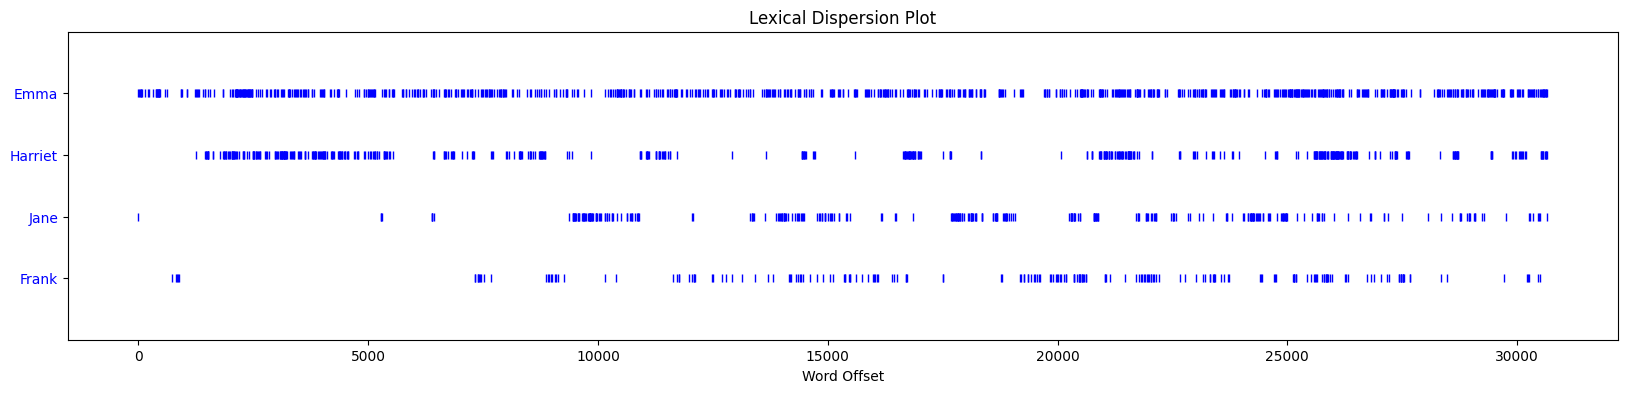

In [155]:
# Emma, Harriet, Jane, Frank      emma 소설 전체에서 어디에 등장하는지
plt.figure(figsize=(20,4))
emma_text.dispersion_plot(['Emma', 'Harriet', 'Jane', 'Frank'])

In [159]:
from nltk import FreqDist
tags = ['NNP', 'NNPS']
name_list = [word for word, tag in tagged_list1 if tag in tags]
name_count = FreqDist(name_list)
name_count

FreqDist({'Emma': 840, 'Mrs': 696, 'Miss': 569, 'Harriet': 484, 'Weston': 433, 'Knightley': 389, 'Elton': 382, 'Jane': 295, 'Woodhouse': 293, 'Fairfax': 241, ...})

In [160]:
for name, count in name_count.items():
    if count>150:
        print(name, ':', count)

Emma : 840
Jane : 295
Woodhouse : 293
Miss : 569
Weston : 433
Mrs : 696
Hartfield : 155
Knightley : 389
Elton : 382
Churchill : 221
Frank : 208
Harriet : 484
Fairfax : 241


In [161]:
name_count_s = pd.Series(name_count)
name_count_s.sort_values(ascending=False, inplace=True)
name_count_s[name_count_s>150]

Emma         840
Mrs          696
Miss         569
Harriet      484
Weston       433
Knightley    389
Elton        382
Jane         295
Woodhouse    293
Fairfax      241
Churchill    221
Frank        208
Hartfield    155
dtype: int64